In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [12]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [14]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [20]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [18]:
df['Age'].fillna(df['Age'].mean(),inplace = True)

C:\Users\omjee\AppData\Local\Temp\ipykernel_17004\1652017284.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace = True)


In [22]:
df.sample(10)

,Survived,Age,Fare
73,0,26.000000,14.4542
692,1,29.699118,56.4958
376,1,22.000000,7.2500
540,1,36.000000,71.0000
360,0,40.000000,27.9000
882,0,22.000000,10.5167
389,1,17.000000,12.0000
475,0,29.699118,52.0000
130,0,33.000000,7.8958
460,1,48.000000,26.5500


In [28]:
X = df.drop('Survived',axis = 1)
y = df['Survived']

In [30]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.33, random_state=42)

C:\Users\omjee\AppData\Local\Temp\ipykernel_17004\2735652938.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


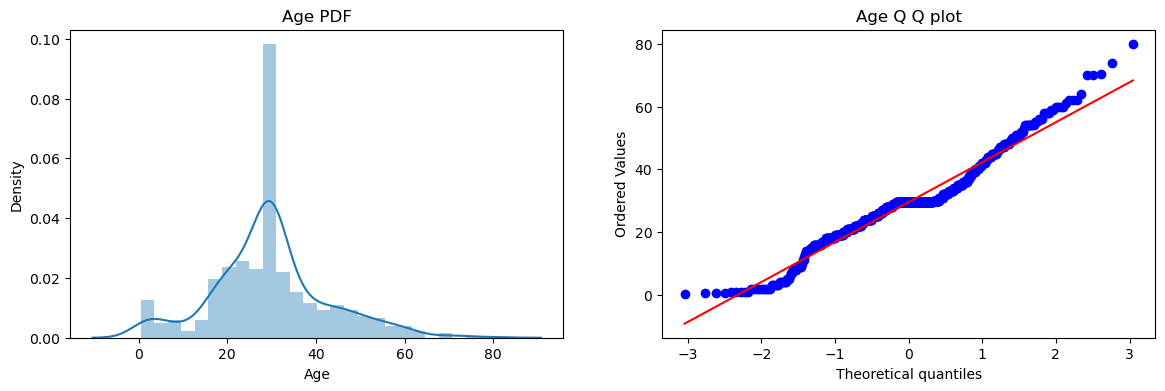

In [44]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title("Age PDF")


# Q Q plot by using stats library
plt.subplot(122)
stats.probplot(X_train['Age'],dist = "norm",plot = plt)
plt.title("Age Q Q plot")
plt.show()

C:\Users\omjee\AppData\Local\Temp\ipykernel_17004\2779622807.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


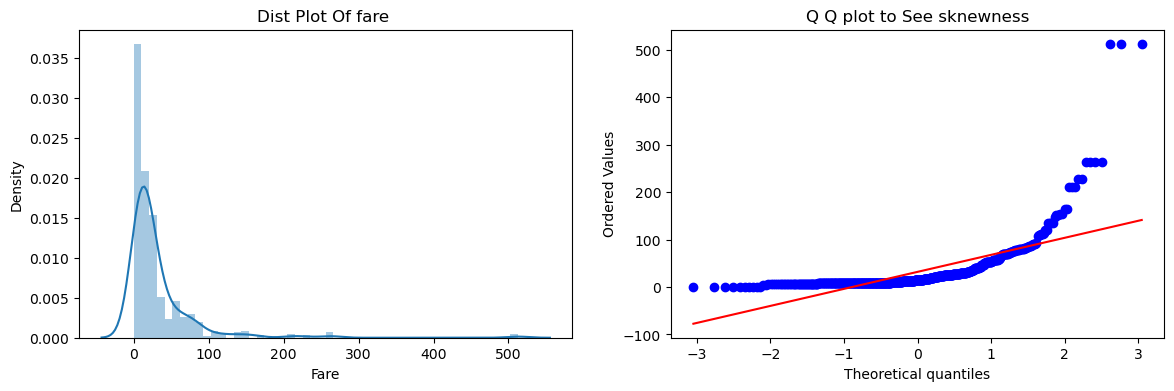

In [46]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title("Dist Plot Of fare ")

plt.subplot(122)
stats.probplot(X_train['Fare'],dist = "norm",plot = plt)
plt.title("Q Q plot to See sknewness")
plt.show()

In [48]:
model1 = LogisticRegression()
model2 = DecisionTreeClassifier()

In [52]:
model1.fit(X_train,y_train) 
model2.fit(X_train,y_train)

y_pred = model1.predict(X_test)
y_pred_2 = model2.predict(X_test)

print("Accuracy Score LR ",accuracy_score(y_test,y_pred))
print("Accuracy Score DT ",accuracy_score(y_test,y_pred_2))

Accuracy Score LR  0.6576271186440678
Accuracy Score DT  0.6305084745762712


In [54]:
trf = FunctionTransformer(func = np.log1p)

In [56]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [58]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [62]:
clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred = clf.predict(X_test_transformed)
y_pred_2 = clf2.predict(X_test_transformed)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred_2))

Accuracy LR 0.6847457627118644
Accuracy DT 0.6576271186440678


In [72]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv = 10)))
print("LR",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv = 10)))

LR 0.678027465667915
LR 0.6555056179775282


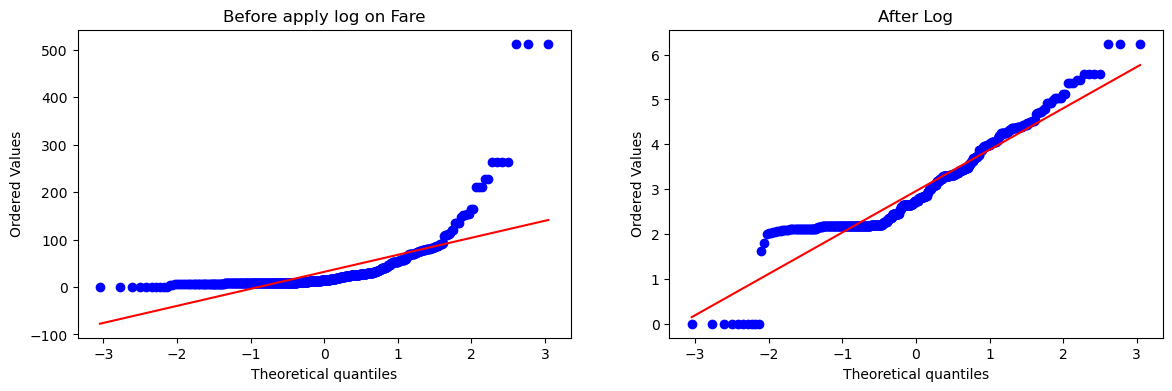

In [74]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Fare'],dist = "norm",plot = plt)
plt.title("Before apply log on Fare")

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'],dist = "norm",plot = plt)
plt.title("After Log")
plt.show()

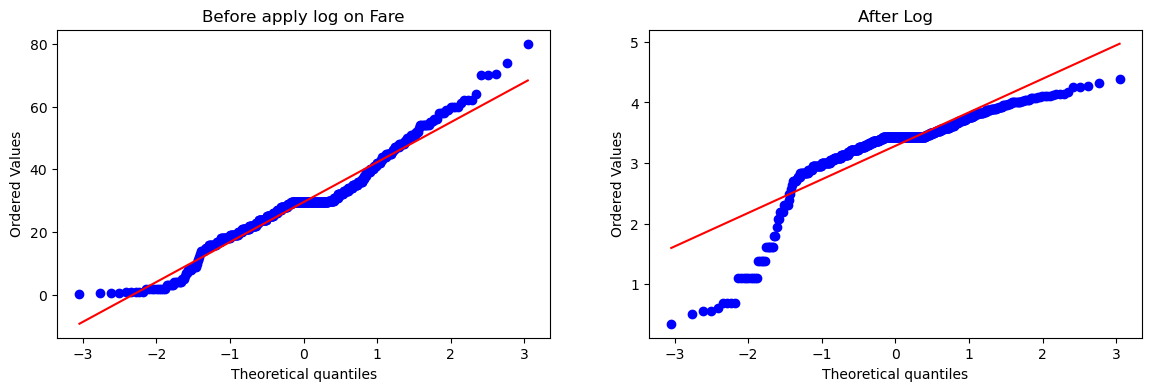

In [76]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Age'],dist = "norm",plot = plt)
plt.title("Before apply log on Fare")

plt.subplot(122)
stats.probplot(X_train_transformed['Age'],dist = "norm",plot = plt)
plt.title("After Log")
plt.show()

In [78]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder = 'passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [80]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6711864406779661
Accuracy DT 0.6440677966101694
